In [ ]:
from google.colab import files
uploaded = files.upload()

Device: cuda
N_BASIS: 32
Train: (14000, 66), Val: (2000, 66), Test: (4000, 66)
Energies E_1..E_5: [0.5    1.4998 2.4996 3.4992 4.4987]



/tmp/ipykernel_644/1385214606.py:253: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


Constrained model parameters:   701,297
Unconstrained model parameters: 637,248

Training: Constrained Transformer (ours)
  model_type=constrained, epochs=10, lr=0.001
  alpha=0.0 (pop aux), beta=0.0 (phase aux)
  NO constraint penalties — hard constraints by architecture
  Epoch   1/10 | train_loss=9.6359e-03 | val_psi=1.0130e-02 | |P-1|=4.18e-08 | |E-E0|=4.80e-07
  Epoch  10/10 | train_loss=8.3858e-03 | val_psi=1.0040e-02 | |P-1|=3.92e-08 | |E-E0|=4.76e-07

  Best val psi_mse: 1.0021e-02

Training: Unconstrained Baseline (soft penalties)
  model_type=unconstrained, epochs=10, lr=0.001
  lambda_P=10.0, lambda_E=10.0 (soft penalties)
  Epoch   1/10 | train_loss=5.9099e+02 | val_psi=5.2315e-02 | |P-1|=2.30e-01 | |E-E0|=4.96e+00
  Epoch  10/10 | train_loss=2.3423e+01 | val_psi=5.5439e-02 | |P-1|=3.39e-02 | |E-E0|=1.21e+00

  Best val psi_mse: 5.2315e-02

TEST RESULTS: Constrained (ours)
  Wavefunction MSE:          8.4745e-03
  |P-1| mean:                4.2722e-08
  |P-1| max:          

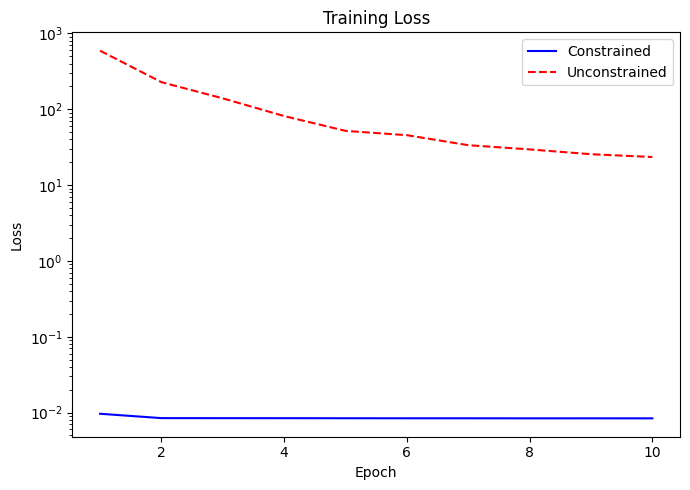

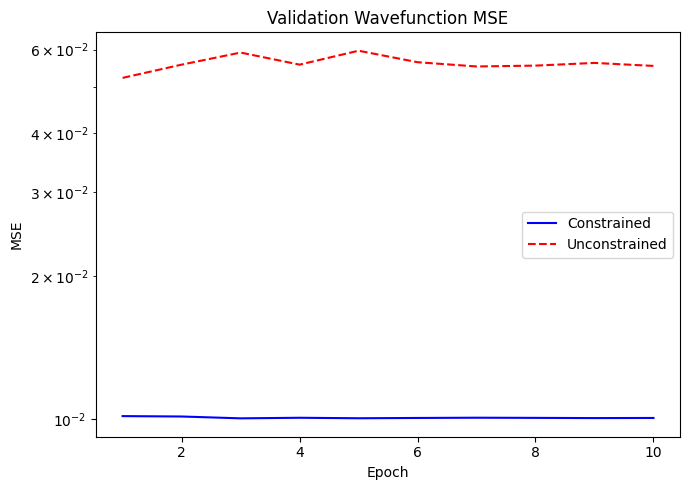

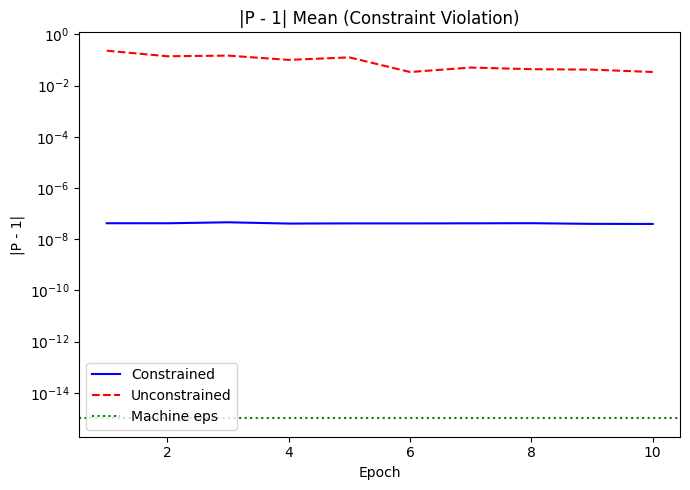

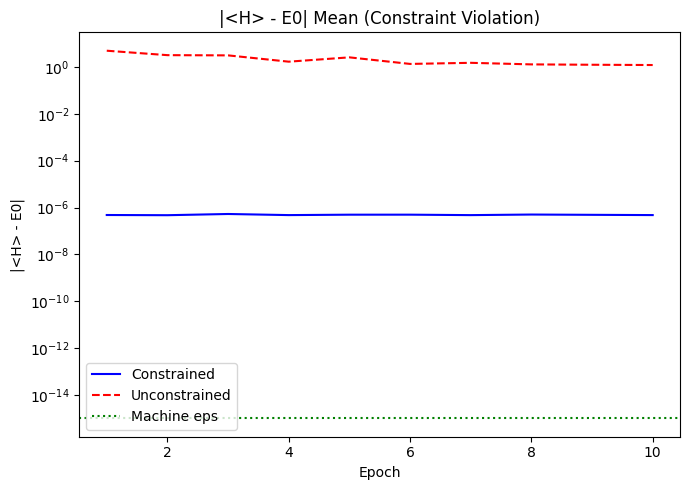

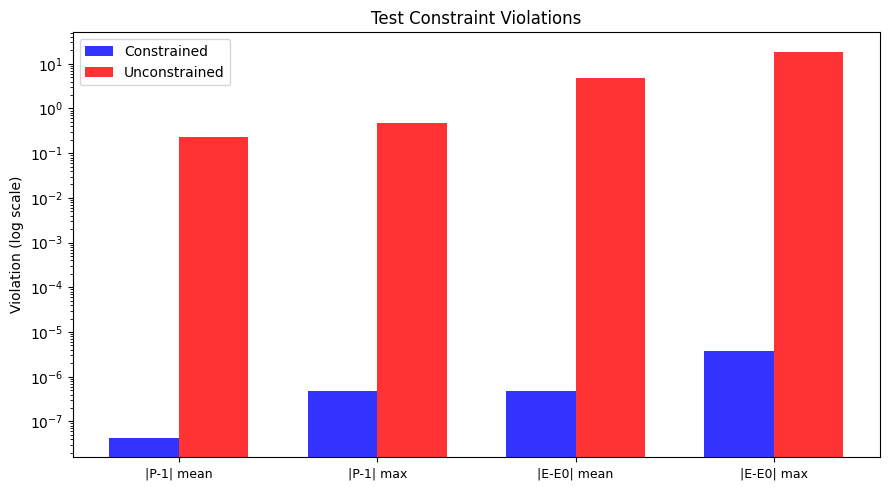

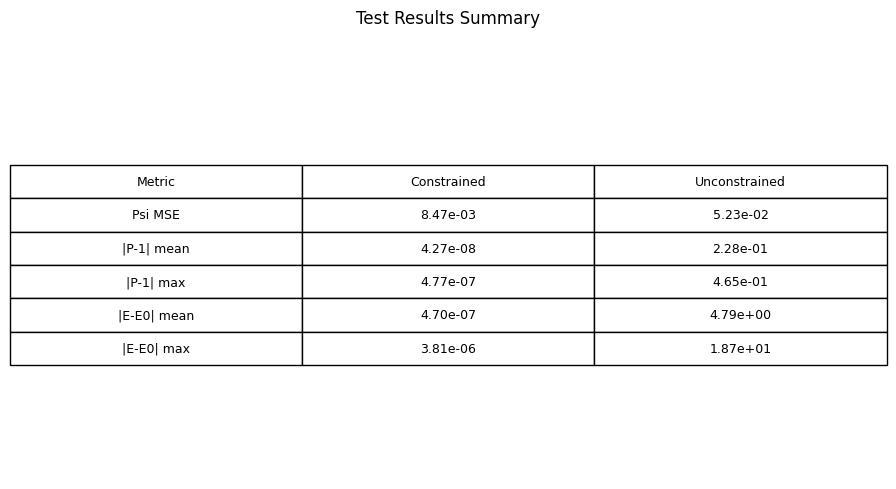

In [ ]:
"""
Constrained Quantum Transformer — Training & Evaluation
  Model A — Constrained Transformer:
    Hard constraints P=1 and <H>=E0 enforced by architecture.
    Loss = wavefunction MSE only. No penalty terms.

  Model B — Unconstrained Baseline Transformer:
    Same architecture backbone. Soft penalty losses for P and E.
    Loss = wavefunction MSE + lambda_P*(P-1)^2 + lambda_E*(E-E0)^2.
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import json
import os
import random
import matplotlib.pyplot as plt

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Load dataset and physical parameters
DATASET_DIR = "quantum_dataset"

X_train = np.load("X_train.npy")   # (14000, 66)
Y_train = np.load("Y_train.npy")   # (14000, 64)
X_val   = np.load("X_val.npy")
Y_val   = np.load("Y_val.npy")
X_test  = np.load("X_test.npy")
Y_test  = np.load("Y_test.npy")

energies = np.load("energies.npy")  # (N_BASIS,) eigenvalues

with open("config.json") as f:
    cfg = json.load(f)

N_BASIS = cfg["N_BASIS"]   # 32
HBAR    = cfg["HBAR"]      # 1.0

print(f"N_BASIS: {N_BASIS}")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Energies E_1..E_5: {energies[:5].round(4)}")
print()

# DATASET
class QuantumDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]


def make_loaders(batch_size=256):
    train_ds = QuantumDataset(X_train, Y_train)
    val_ds   = QuantumDataset(X_val,   Y_val)
    test_ds  = QuantumDataset(X_test,  Y_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader


# HARD-CONSTRAINED POPULATION LAYER

class HardConstrainedPopulationLayer(nn.Module):

    def __init__(self, energies_np, n_basis):
        super().__init__()
        self.n_basis = n_basis
        # Register energies as buffer
        self.register_buffer(
            "energies",
            torch.tensor(energies_np, dtype=torch.float32)
        )

        # Precompute all pairs (i, j) with E_i < E_j
        pairs = []
        for i in range(n_basis):
            for j in range(i + 1, n_basis):
                pairs.append((i, j))
        self.pairs = pairs          # list of (i,j) tuples
        self.n_pairs = len(pairs)   # max possible logits = N*(N-1)/2

        # Index tensors for vectorized vertex construction
        self.register_buffer(
            "pair_i",
            torch.tensor([p[0] for p in pairs], dtype=torch.long)
        )
        self.register_buffer(
            "pair_j",
            torch.tensor([p[1] for p in pairs], dtype=torch.long)
        )

    def forward(self, logits, E0):
        batch_size = logits.shape[0]
        E_i = self.energies[self.pair_i]   # (n_pairs,)
        E_j = self.energies[self.pair_j]   # (n_pairs,)

        # ── Per-sample feasibility mask
        E0_exp = E0.unsqueeze(1)            # (batch, 1)
        feasible = (
            (E_i.unsqueeze(0) < E0_exp) &  # (batch, n_pairs)
            (E_j.unsqueeze(0) > E0_exp)
        )                                   # (batch, n_pairs) bool

        # ── Mask infeasible logits with large negative value
        masked_logits = logits.masked_fill(~feasible, -1e9)

        # ── Softmax over feasible pairs
        w = torch.softmax(masked_logits, dim=1)   # (batch, n_pairs)

        # ── Vertex coordinates
        denom   = E_j.unsqueeze(0) - E_i.unsqueeze(0)   # (batch, n_pairs)
        lam     = (E_j.unsqueeze(0) - E0_exp) / denom   # (batch, n_pairs)
        one_lam = (E0_exp - E_i.unsqueeze(0)) / denom   # (batch, n_pairs)

        # ── Weighted sum of vertices
        p = torch.zeros(batch_size, self.n_basis, device=logits.device)

        # Contribution from e_i component: w_ij * lam_ij added to p[:, i]
        p.scatter_add_(
            1,
            self.pair_i.unsqueeze(0).expand(batch_size, -1),
            w * lam
        )
        # Contribution from e_j component: w_ij * (1-lam_ij) added to p[:, j]
        p.scatter_add_(
            1,
            self.pair_j.unsqueeze(0).expand(batch_size, -1),
            w * one_lam
        )

        return p


# TRANSFORMER BACKBONE (shared by both models)

class TimeEmbedding(nn.Module):
    """Sinusoidal + learned time embedding injected into every token."""
    def __init__(self, d_model):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model)
        )

    def forward(self, t):
        return self.proj(t.unsqueeze(-1))


class QuantumTransformerBackbone(nn.Module):
    def __init__(self, n_basis, d_model=128, n_heads=4, n_layers=3,
                 dropout=0.1):
        super().__init__()
        self.n_basis  = n_basis
        self.d_model  = d_model

        # Token embedding: 3 features (Re, Im, E_n) -> d_model
        self.token_embed = nn.Linear(3, d_model)

        # Time embedding
        self.time_embed = TimeEmbedding(d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            norm_first=True        # Pre-norm for stability
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers
        )

        # CLS token for global representation
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        # Layer norm on output
        self.norm = nn.LayerNorm(d_model)

    def forward(self, c0_real, c0_imag, energies_batch, t):
        batch = c0_real.shape[0]

        # Build tokens: (Re(c_n), Im(c_n), E_n)  shape (batch, n_basis, 3)
        tokens = torch.stack([c0_real, c0_imag, energies_batch], dim=-1)
        tokens = self.token_embed(tokens)             # (batch, n_basis, d_model)

        # Time embedding — additive to all tokens
        t_emb = self.time_embed(t).unsqueeze(1)       # (batch, 1, d_model)
        tokens = tokens + t_emb

        # Prepend CLS token
        cls = self.cls_token.expand(batch, -1, -1)    # (batch, 1, d_model)
        tokens = torch.cat([cls, tokens], dim=1)       # (batch, 1+n_basis, d_model)

        # Transformer
        out = self.transformer(tokens)                 # (batch, 1+n_basis, d_model)
        out = self.norm(out)

        h_global = out[:, 0, :]                        # (batch, d_model)  — CLS
        h_states = out[:, 1:, :]                       # (batch, n_basis, d_model)

        return h_states, h_global


# MODEL A — CONSTRAINED TRANSFORMER

class ConstrainedQuantumTransformer(nn.Module):

    def __init__(self, n_basis, energies_np, d_model=128, n_heads=4,
                 n_layers=3, dropout=0.1):
        super().__init__()
        self.n_basis = n_basis
        self.register_buffer(
            "energies",
            torch.tensor(energies_np, dtype=torch.float32)
        )

        # Shared backbone
        self.backbone = QuantumTransformerBackbone(
            n_basis, d_model, n_heads, n_layers, dropout
        )

        # Hard-constrained population layer
        self.pop_layer = HardConstrainedPopulationLayer(energies_np, n_basis)
        n_pairs = self.pop_layer.n_pairs

        # Population logit head: global latent -> z_ij
        self.pop_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, n_pairs)
        )

        # Phase residual head: per-state latent -> delta_theta_n
        self.phase_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.SiLU(),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        # ── Unpack input
        c0_real = x[:, :self.n_basis]                 # (batch, n_basis)
        c0_imag = x[:, self.n_basis:2*self.n_basis]   # (batch, n_basis)
        t       = x[:, 2*self.n_basis]                # (batch,)
        E0      = x[:, 2*self.n_basis + 1]            # (batch,)

        # ── Initial phase from input
        theta0 = torch.atan2(c0_imag, c0_real)        # (batch, n_basis)

        # ── Backbone
        E_batch = self.energies.unsqueeze(0).expand(x.shape[0], -1)
        h_states, h_global = self.backbone(c0_real, c0_imag, E_batch, t)

        # ── Population: hard-constrained
        logits = self.pop_head(h_global)               # (batch, n_pairs)
        p_pred = self.pop_layer(logits, E0)            # (batch, n_basis)


        # ── Phase: theta_n(0) - E_n*t/hbar + delta_theta_n
        free_phase = (
            self.energies.unsqueeze(0) *
            t.unsqueeze(1) / HBAR
        )                                              # (batch, n_basis)

        delta_theta = self.phase_head(h_states).squeeze(-1)  # (batch, n_basis)
        theta_pred  = theta0 - free_phase + delta_theta       # (batch, n_basis)

        # ── Reconstruct wavefunction: c_n = sqrt(p_n) * exp(i*theta_n)
        amp            = torch.sqrt(p_pred.clamp(min=1e-12))
        psi_pred_real  = amp * torch.cos(theta_pred)
        psi_pred_imag  = amp * torch.sin(theta_pred)

        return psi_pred_real, psi_pred_imag, p_pred, theta_pred


# MODEL B — UNCONSTRAINED BASELINE

class UnconstrainedBaselineTransformer(nn.Module):

    def __init__(self, n_basis, energies_np, d_model=128, n_heads=4,
                 n_layers=3, dropout=0.1):
        super().__init__()
        self.n_basis = n_basis
        self.register_buffer(
            "energies",
            torch.tensor(energies_np, dtype=torch.float32)
        )

        self.backbone = QuantumTransformerBackbone(
            n_basis, d_model, n_heads, n_layers, dropout
        )

        # Direct coefficient prediction head
        self.coeff_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.SiLU(),
            nn.Linear(d_model, 2 * n_basis)   # Re and Im concatenated
        )

    def forward(self, x):
        c0_real = x[:, :self.n_basis]
        c0_imag = x[:, self.n_basis:2*self.n_basis]
        t       = x[:, 2*self.n_basis]
        E0      = x[:, 2*self.n_basis + 1]

        E_batch = self.energies.unsqueeze(0).expand(x.shape[0], -1)
        h_states, h_global = self.backbone(c0_real, c0_imag, E_batch, t)

        # Direct prediction — no constraint enforcement
        out            = self.coeff_head(h_global)          # (batch, 2*n_basis)
        psi_pred_real  = out[:, :self.n_basis]
        psi_pred_imag  = out[:, self.n_basis:]

        # Compute populations
        p_pred = psi_pred_real**2 + psi_pred_imag**2

        return psi_pred_real, psi_pred_imag, p_pred, E0


# LOSS FUNCTIONS

def wavefunction_mse(pred_real, pred_imag, true_real, true_imag):
    """Primary loss: ||psi_pred - psi_true||^2"""
    loss_real = (pred_real - true_real)**2
    loss_imag = (pred_imag - true_imag)**2
    return (loss_real + loss_imag).mean()


def constrained_loss(pred_real, pred_imag, true_real, true_imag,
                     p_pred, theta_pred, true_real_t, true_imag_t,
                     alpha=0.0, beta=0.0):
    loss_psi = wavefunction_mse(pred_real, pred_imag, true_real, true_imag)

    total = loss_psi

    if alpha > 0.0:
        p_true = true_real**2 + true_imag**2
        loss_p = ((p_pred - p_true)**2).mean()
        total  = total + alpha * loss_p

    if beta > 0.0:
        theta_true = torch.atan2(true_imag, true_real)
        loss_theta = (1.0 - torch.cos(theta_pred - theta_true)).mean()
        total      = total + beta * loss_theta

    return total, loss_psi


def unconstrained_loss(pred_real, pred_imag, true_real, true_imag,
                       p_pred, E0, energies, lambda_P=1.0, lambda_E=1.0):
    loss_psi = wavefunction_mse(pred_real, pred_imag, true_real, true_imag)

    # Soft probability penalty: lambda_P * (sum p_n - 1)^2
    P_pred     = p_pred.sum(dim=1)            # (batch,)
    loss_prob  = ((P_pred - 1.0)**2).mean()

    # Soft energy penalty: lambda_E * (sum E_n p_n - E0)^2
    E_pred     = (energies.unsqueeze(0) * p_pred).sum(dim=1)  # (batch,)
    loss_energy = ((E_pred - E0)**2).mean()

    total = loss_psi + lambda_P * loss_prob + lambda_E * loss_energy

    return total, loss_psi


# PHYSICAL CONSTRAINT METRICS (for evaluation — not training)

def compute_constraint_metrics(pred_real, pred_imag, E0_batch, energies):
    p_pred = pred_real**2 + pred_imag**2       # (batch, n_basis)

    # Probability violation: |sum p_n - 1|
    P_pred       = p_pred.sum(dim=1)           # (batch,)
    prob_viol    = (P_pred - 1.0).abs()        # (batch,)

    # Energy violation: |sum E_n p_n - E0|
    E_pred       = (energies.unsqueeze(0) * p_pred).sum(dim=1)  # (batch,)
    energy_viol  = (E_pred - E0_batch).abs()   # (batch,)

    return {
        "prob_violation_mean":   prob_viol.mean().item(),
        "prob_violation_max":    prob_viol.max().item(),
        "energy_violation_mean": energy_viol.mean().item(),
        "energy_violation_max":  energy_viol.max().item(),
    }


# TRAINING LOOP
def train_one_epoch(model, loader, optimizer, model_type,
                    energies_t, alpha=0.0, beta=0.0,
                    lambda_P=1.0, lambda_E=1.0):
    model.train()
    total_loss = 0.0
    total_psi  = 0.0
    n_batches  = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        true_real = y[:, :N_BASIS]
        true_imag = y[:, N_BASIS:]
        E0        = x[:, 2*N_BASIS + 1]

        optimizer.zero_grad()

        pred_real, pred_imag, p_pred, aux = model(x)

        if model_type == "constrained":
            theta_pred = aux
            loss, loss_psi = constrained_loss(
                pred_real, pred_imag, true_real, true_imag,
                p_pred, theta_pred, true_real, true_imag,
                alpha=alpha, beta=beta
            )
        else:
            loss, loss_psi = unconstrained_loss(
                pred_real, pred_imag, true_real, true_imag,
                p_pred, E0, energies_t,
                lambda_P=lambda_P, lambda_E=lambda_E
            )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_psi  += loss_psi.item()
        n_batches  += 1

    return total_loss / n_batches, total_psi / n_batches


# QUANTUM FIDELITY

@torch.no_grad()
def quantum_fidelity(y_true, y_pred):

    n_basis = y_true.shape[1] // 2

    # Reconstruct complex coefficients
    true_real = y_true[:, :n_basis]
    true_imag = y_true[:, n_basis:]

    pred_real = y_pred[:, :n_basis]
    pred_imag = y_pred[:, n_basis:]

    psi_true = torch.complex(true_real, true_imag)
    psi_pred = torch.complex(pred_real, pred_imag)

    # Normalize both states
    true_norm = torch.sqrt(
        torch.sum(torch.abs(psi_true) ** 2, dim=1, keepdim=True)
    )

    pred_norm = torch.sqrt(
        torch.sum(torch.abs(psi_pred) ** 2, dim=1, keepdim=True)
    )

    psi_true = psi_true / true_norm.clamp_min(1e-12)
    psi_pred = psi_pred / pred_norm.clamp_min(1e-12)

    # <psi_true | psi_pred>
    overlap = torch.sum(
        torch.conj(psi_true) * psi_pred,
        dim=1
    )

    # F = |overlap|^2
    fidelity = torch.abs(overlap) ** 2

    return fidelity

def evaluate(model, loader, model_type, energies_t,
             alpha=0.0, beta=0.0, lambda_P=1.0, lambda_E=1.0):
    model.eval()
    total_loss   = 0.0
    total_psi    = 0.0
    all_metrics  = {
        "prob_violation_mean":   [],
        "prob_violation_max":    [],
        "energy_violation_mean": [],
        "energy_violation_max":  [],
        "fidelity": []
    }
    n_batches = 0

    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        true_real = y[:, :N_BASIS]
        true_imag = y[:, N_BASIS:]
        E0        = x[:, 2*N_BASIS + 1]

        pred_real, pred_imag, p_pred, aux = model(x)
        pred = torch.cat([pred_real, pred_imag], dim=1)

        fid = quantum_fidelity(y, pred)
        all_metrics["fidelity"].extend(fid.detach().cpu().numpy())

        if model_type == "constrained":
            theta_pred = aux
            loss, loss_psi = constrained_loss(
                pred_real, pred_imag, true_real, true_imag,
                p_pred, theta_pred, true_real, true_imag,
                alpha=alpha, beta=beta
            )
        else:
            loss, loss_psi = unconstrained_loss(
                pred_real, pred_imag, true_real, true_imag,
                p_pred, E0, energies_t,
                lambda_P=lambda_P, lambda_E=lambda_E
            )

        metrics = compute_constraint_metrics(
            pred_real, pred_imag, E0, energies_t
        )
        for k, v in metrics.items():
            all_metrics[k].append(v)

        total_loss += loss.item()
        total_psi  += loss_psi.item()
        n_batches  += 1

    return {
    "loss":     total_loss / n_batches,
    "psi_mse":  total_psi  / n_batches,

    "prob_violation_mean":   np.mean(all_metrics["prob_violation_mean"]),
    "prob_violation_max":    np.max(all_metrics["prob_violation_max"]),

    "energy_violation_mean": np.mean(all_metrics["energy_violation_mean"]),
    "energy_violation_max":  np.max(all_metrics["energy_violation_max"]),

    "fidelity_mean":   np.mean(all_metrics["fidelity"]),
    "fidelity_median": np.median(all_metrics["fidelity"]),
    }


# FULL TRAINING RUN

def train_model(model, model_type, n_epochs=10, lr=1e-3,
                batch_size=256, alpha=0.0, beta=0.0,
                lambda_P=1.0, lambda_E=1.0, label="model"):

    print(f"\n{'='*60}")
    print(f"Training: {label}")
    print(f"  model_type={model_type}, epochs={n_epochs}, lr={lr}")
    if model_type == "constrained":
        print(f"  alpha={alpha} (pop aux), beta={beta} (phase aux)")
        print(f"  NO constraint penalties — hard constraints by architecture")
    else:
        print(f"  lambda_P={lambda_P}, lambda_E={lambda_E} (soft penalties)")
    print(f"{'='*60}")

    train_loader, val_loader, _ = make_loaders(batch_size)
    energies_t = torch.tensor(energies, dtype=torch.float32).to(DEVICE)

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=lr * 0.01
    )

    history = {
        "train_loss": [], "val_loss": [],
        "val_psi_mse": [],
        "val_prob_viol_mean": [], "val_prob_viol_max": [],
        "val_energy_viol_mean": [], "val_energy_viol_max": [],
    }

    best_val_psi = float("inf")
    best_state   = None

    for epoch in range(1, n_epochs + 1):
        train_loss, _ = train_one_epoch(
            model, train_loader, optimizer, model_type,
            energies_t, alpha=alpha, beta=beta,
            lambda_P=lambda_P, lambda_E=lambda_E
        )
        val_metrics = evaluate(
            model, val_loader, model_type, energies_t,
            alpha=alpha, beta=beta,
            lambda_P=lambda_P, lambda_E=lambda_E
        )
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_psi_mse"].append(val_metrics["psi_mse"])
        history["val_prob_viol_mean"].append(val_metrics["prob_violation_mean"])
        history["val_prob_viol_max"].append(val_metrics["prob_violation_max"])
        history["val_energy_viol_mean"].append(val_metrics["energy_violation_mean"])
        history["val_energy_viol_max"].append(val_metrics["energy_violation_max"])

        if val_metrics["psi_mse"] < best_val_psi:
            best_val_psi = val_metrics["psi_mse"]
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(
                f"  Epoch {epoch:3d}/{n_epochs} | "
                f"train_loss={train_loss:.4e} | "
                f"val_psi={val_metrics['psi_mse']:.4e} | "
                f"|P-1|={val_metrics['prob_violation_mean']:.2e} | "
                f"|E-E0|={val_metrics['energy_violation_mean']:.2e}"
            )

    # Restore best checkpoint
    model.load_state_dict(best_state)
    print(f"\n  Best val psi_mse: {best_val_psi:.4e}")

    return history


# TEST EVALUATION AND RESULTS TABLE
@torch.no_grad()
def test_evaluation(model, model_type, label):
    _, _, test_loader = make_loaders(batch_size=256)
    energies_t = torch.tensor(energies, dtype=torch.float32).to(DEVICE)

    metrics = evaluate(
        model, test_loader, model_type, energies_t,
        lambda_P=1.0, lambda_E=1.0
    )

    print(f"\n{'='*60}")
    print(f"TEST RESULTS: {label}")
    print(f"{'='*60}")
    print(f"  Wavefunction MSE:          {metrics['psi_mse']:.4e}")
    print(f"  |P-1| mean:                {metrics['prob_violation_mean']:.4e}")
    print(f"  |P-1| max:                 {metrics['prob_violation_max']:.4e}")
    print(f"  |<H>-E0| mean:             {metrics['energy_violation_mean']:.4e}")
    print(f"  |<H>-E0| max:              {metrics['energy_violation_max']:.4e}")
    print(f"Fidelity mean:   {metrics['fidelity_mean']:.8f}")
    print(f"Fidelity median: {metrics['fidelity_median']:.8f}")

    return metrics


# PLOTTING
def plot_results(hist_c, hist_u, metrics_c, metrics_u):

    epochs = range(1, len(hist_c["train_loss"]) + 1)

    # 1. TRAINING LOSS
    plt.figure(figsize=(7, 5))

    plt.semilogy(
        epochs,
        hist_c["train_loss"],
        label="Constrained",
        color="blue"
    )

    plt.semilogy(
        epochs,
        hist_u["train_loss"],
        label="Unconstrained",
        color="red",
        linestyle="--"
    )

    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()



    # 2. VALIDATION WAVEFUNCTION MSE

    plt.figure(figsize=(7, 5))

    plt.semilogy(
        epochs,
        hist_c["val_psi_mse"],
        label="Constrained",
        color="blue"
    )

    plt.semilogy(
        epochs,
        hist_u["val_psi_mse"],
        label="Unconstrained",
        color="red",
        linestyle="--"
    )

    plt.title("Validation Wavefunction MSE")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()



    # 3. PROBABILITY VIOLATION

    plt.figure(figsize=(7, 5))

    plt.semilogy(
        epochs,
        np.array(hist_c["val_prob_viol_mean"]) + 1e-20,
        label="Constrained",
        color="blue"
    )

    plt.semilogy(
        epochs,
        hist_u["val_prob_viol_mean"],
        label="Unconstrained",
        color="red",
        linestyle="--"
    )

    plt.axhline(
        1e-15,
        color="green",
        linestyle=":",
        label="Machine eps"
    )

    plt.title("|P - 1| Mean (Constraint Violation)")
    plt.xlabel("Epoch")
    plt.ylabel("|P - 1|")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()



    # 4. ENERGY VIOLATION

    plt.figure(figsize=(7, 5))

    plt.semilogy(
        epochs,
        np.array(hist_c["val_energy_viol_mean"]) + 1e-20,
        label="Constrained",
        color="blue"
    )

    plt.semilogy(
        epochs,
        hist_u["val_energy_viol_mean"],
        label="Unconstrained",
        color="red",
        linestyle="--"
    )

    plt.axhline(
        1e-15,
        color="green",
        linestyle=":",
        label="Machine eps"
    )

    plt.title("|<H> - E0| Mean (Constraint Violation)")
    plt.xlabel("Epoch")
    plt.ylabel("|<H> - E0|")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()



    # 5. TEST CONSTRAINT VIOLATIONS — BAR CHART

    plt.figure(figsize=(9, 5))

    metrics_names = [
        "|P-1| mean",
        "|P-1| max",
        "|E-E0| mean",
        "|E-E0| max"
    ]

    vals_c = [
        metrics_c["prob_violation_mean"],
        metrics_c["prob_violation_max"],
        metrics_c["energy_violation_mean"],
        metrics_c["energy_violation_max"],
    ]

    vals_u = [
        metrics_u["prob_violation_mean"],
        metrics_u["prob_violation_max"],
        metrics_u["energy_violation_mean"],
        metrics_u["energy_violation_max"],
    ]

    x_pos = np.arange(len(metrics_names))
    width = 0.35

    plt.bar(
        x_pos - width / 2,
        [max(v, 1e-20) for v in vals_c],
        width,
        label="Constrained",
        color="blue",
        alpha=0.8
    )

    plt.bar(
        x_pos + width / 2,
        [max(v, 1e-20) for v in vals_u],
        width,
        label="Unconstrained",
        color="red",
        alpha=0.8
    )

    plt.yscale("log")
    plt.xticks(
        x_pos,
        metrics_names,
        fontsize=9
    )

    plt.title("Test Constraint Violations")
    plt.ylabel("Violation (log scale)")
    plt.legend()

    plt.tight_layout()
    plt.show()
    plt.close()



    # 6. TEST RESULTS SUMMARY TABLE

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.axis("off")

    table_data = [
        ["Metric", "Constrained", "Unconstrained"],

        [
            "Psi MSE",
            f"{metrics_c['psi_mse']:.2e}",
            f"{metrics_u['psi_mse']:.2e}"
        ],

        [
            "|P-1| mean",
            f"{metrics_c['prob_violation_mean']:.2e}",
            f"{metrics_u['prob_violation_mean']:.2e}"
        ],

        [
            "|P-1| max",
            f"{metrics_c['prob_violation_max']:.2e}",
            f"{metrics_u['prob_violation_max']:.2e}"
        ],

        [
            "|E-E0| mean",
            f"{metrics_c['energy_violation_mean']:.2e}",
            f"{metrics_u['energy_violation_mean']:.2e}"
        ],

        [
            "|E-E0| max",
            f"{metrics_c['energy_violation_max']:.2e}",
            f"{metrics_u['energy_violation_max']:.2e}"
        ],
    ]

    tbl = ax.table(
        cellText=table_data[1:],
        colLabels=table_data[0],
        cellLoc="center",
        loc="center"
    )

    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1.2, 1.8)

    ax.set_title(
        "Test Results Summary",
        pad=20
    )

    plt.tight_layout()
    plt.show()
    plt.close(fig)



# MAIN

if __name__ == "__main__":

    # ── Hyperparameters
    D_MODEL   = 128
    N_HEADS   = 4
    N_LAYERS  = 3
    DROPOUT   = 0.1
    N_EPOCHS  = 10
    LR        = 1e-3
    BATCH     = 256

    # Soft penalty weights for unconstrained baseline
    LAMBDA_P  = 10.0   # weight on |P-1|^2 penalty
    LAMBDA_E  = 10.0   # weight on |<H>-E0|^2 penalty

    # ── Build models
    model_c = ConstrainedQuantumTransformer(
        n_basis=N_BASIS,
        energies_np=energies,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)

    model_u = UnconstrainedBaselineTransformer(
        n_basis=N_BASIS,
        energies_np=energies,
        d_model=D_MODEL,
        n_heads=N_HEADS,
        n_layers=N_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)

    n_params_c = sum(p.numel() for p in model_c.parameters())
    n_params_u = sum(p.numel() for p in model_u.parameters())
    print(f"Constrained model parameters:   {n_params_c:,}")
    print(f"Unconstrained model parameters: {n_params_u:,}")

    # ── Train constrained model
    hist_c = train_model(
        model_c,
        model_type="constrained",
        n_epochs=N_EPOCHS,
        lr=LR,
        batch_size=BATCH,
        alpha=0.0,   # no auxiliary population supervision
        beta=0.0,    # no auxiliary phase supervision
        label="Constrained Transformer (ours)"
    )

    # ── Train unconstrained baseline
    hist_u = train_model(
        model_u,
        model_type="unconstrained",
        n_epochs=N_EPOCHS,
        lr=LR,
        batch_size=BATCH,
        lambda_P=LAMBDA_P,
        lambda_E=LAMBDA_E,
        label="Unconstrained Baseline (soft penalties)"
    )

    # ── Test evaluation
    metrics_c = test_evaluation(model_c, "constrained",   "Constrained")
    metrics_u = test_evaluation(model_u, "unconstrained", "Unconstrained baseline")

    # ── Key result printout
    print(f"\n{'='*60}")
    print("KEY RESEARCH RESULT")
    print(f"{'='*60}")
    print(
        f"Probability constraint |P-1|:\n"
        f"  Constrained:   {metrics_c['prob_violation_mean']:.2e} (mean)  "
        f"{metrics_c['prob_violation_max']:.2e} (max)\n"
        f"  Unconstrained: {metrics_u['prob_violation_mean']:.2e} (mean)  "
        f"{metrics_u['prob_violation_max']:.2e} (max)"
    )
    print(
        f"\nEnergy constraint |<H>-E0|:\n"
        f"  Constrained:   {metrics_c['energy_violation_mean']:.2e} (mean)  "
        f"{metrics_c['energy_violation_max']:.2e} (max)\n"
        f"  Unconstrained: {metrics_u['energy_violation_mean']:.2e} (mean)  "
        f"{metrics_u['energy_violation_max']:.2e} (max)"
    )
    print(
        f"\nWavefunction prediction MSE:\n"
        f"  Constrained:   {metrics_c['psi_mse']:.4e}\n"
        f"  Unconstrained: {metrics_u['psi_mse']:.4e}"
    )

    c_prob_better  = (metrics_u['prob_violation_mean'] /
                      max(metrics_c['prob_violation_mean'], 1e-20))
    c_energy_better = (metrics_u['energy_violation_mean'] /
                       max(metrics_c['energy_violation_mean'], 1e-20))
    print(
        f"\nConstraint improvement factor:\n"
        f"  |P-1|:   {c_prob_better:.1e}x better\n"
        f"  |E-E0|:  {c_energy_better:.1e}x better"
    )
    # ── Plot results
    plot_results(
        hist_c,
        hist_u,
        metrics_c,
        metrics_u
    )